Cell 1 — Drive 인증 & 폴더 내 파일 목록 확인

In [2]:
from google.colab import auth
auth.authenticate_user()
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
import io, os, re

drive_service = build('drive', 'v3')

FOLDER_ID = '15Oj6qYAawgsryhq8CpPZh3HIWhnoriiq'  # 최종 > 상관관계분석
LOCAL_DIR = '/content/esg_scores'
os.makedirs(LOCAL_DIR, exist_ok=True)

files = drive_service.files().list(
    q=f"'{FOLDER_ID}' in parents and trashed=false",
    fields="files(id, name)", pageSize=100
).execute().get('files', [])
print(f"파일 수: {len(files)}")  # 27이어야 정상

파일 수: 27


Cell 2 — 로컬로 다운로드

In [3]:
for f in files:
    fh = io.FileIO(os.path.join(LOCAL_DIR, f['name']), 'wb')
    downloader = MediaIoBaseDownload(fh, drive_service.files().get_media(fileId=f['id']))
    done = False
    while not done:
        _, done = downloader.next_chunk()
    fh.close()
print("다운로드 완료")

다운로드 완료


Cell 3 — long format 추출 (01_ESG통합진단마스터 시트, B=항목코드/D=영역/L=채점유형/X=점수)

In [6]:
import openpyxl, os, re
import pandas as pd

# 1. 파일명에서 불필요한 '의 사본' 제거하고 .xlsx로 이름 일괄 정리
for fname in os.listdir(LOCAL_DIR):
    if '.xlsx' in fname and not fname.endswith('.xlsx'):
        # .xlsx 뒤에 붙은 모든 텍스트('의 사본' 등) 제거
        clean_name = re.sub(r'(\.xlsx).*$', r'\1', fname)
        old_path = os.path.join(LOCAL_DIR, fname)
        new_path = os.path.join(LOCAL_DIR, clean_name)
        os.rename(old_path, new_path)
        print(f"이름 정리 완료: {fname} -> {clean_name}")

# 2. 정리된 .xlsx 파일 대상 추출
pattern = re.compile(r'\((\d{6})\)(.+?)_(\d{4})_')
records = []

excel_files = [f for f in os.listdir(LOCAL_DIR) if f.endswith('.xlsx') and not f.startswith('~$')]
print(f"\n정리 후 처리 대상 파일 수: {len(excel_files)}")

for fname in excel_files:
    m = pattern.search(fname)
    if not m:
        print(f"⚠️ 파일명 매칭 실패: {fname}")
        continue
    code, name, year = m.group(1), m.group(2).strip(), int(m.group(3))

    file_path = os.path.join(LOCAL_DIR, fname)
    try:
        wb = openpyxl.load_workbook(file_path, data_only=True)
    except Exception as e:
        print(f"⚠️ 파일 열기 실패 ({fname}): {e}")
        continue

    if '01_ESG통합진단마스터' not in wb.sheetnames:
        print(f"⚠️ 시트 없음 ('01_ESG통합진단마스터') in {fname}")
        continue

    ws = wb['01_ESG통합진단마스터']
    for r in range(2, ws.max_row + 1):
        item_code = ws.cell(r, 2).value  # B열 (항목코드)
        if item_code is None or str(item_code).strip() == '':
            continue
        records.append({
            '기업코드': code,
            '기업명': name,
            '연도': year,
            '항목코드': str(item_code).strip(),
            '영역': ws.cell(r, 4).value,       # D열
            '채점유형': ws.cell(r, 12).value,   # L열
            '점수': ws.cell(r, 24).value       # X열
        })

df_long = pd.DataFrame(records)
print("\n추출 완료!")
print(f"행 수 및 형태: {df_long.shape}, 고유 기업 수: {df_long['기업코드'].nunique()}, 고유 연도 수: {df_long['연도'].nunique()}")

이름 정리 완료: (007340)DN오토모티브_2023_채점완료.xlsx의 사본의 사본 -> (007340)DN오토모티브_2023_채점완료.xlsx
이름 정리 완료: (267260)HD현대일렉트릭_2024_채점완료.xlsx의 사본의 사본 -> (267260)HD현대일렉트릭_2024_채점완료.xlsx
이름 정리 완료: (000660)SK하이닉스_2024_채점완료.xlsx의 사본의 사본 -> (000660)SK하이닉스_2024_채점완료.xlsx
이름 정리 완료: (067310)하나마이크론_2025_채점완료.xlsx의 사본의 사본 -> (067310)하나마이크론_2025_채점완료.xlsx
이름 정리 완료: (000660)SK하이닉스_2025_채점완료.xlsx의 사본의 사본 -> (000660)SK하이닉스_2025_채점완료.xlsx
이름 정리 완료: (007340)DN오토모티브_2025_채점완료.xlsx의 사본의 사본 -> (007340)DN오토모티브_2025_채점완료.xlsx
이름 정리 완료: (361610)SK아이이테크놀로지_2023_채점완료.xlsx의 사본의 사본 -> (361610)SK아이이테크놀로지_2023_채점완료.xlsx
이름 정리 완료: (010120)엘에스일렉트릭_2023_채점완료.xlsx의 사본의 사본 -> (010120)엘에스일렉트릭_2023_채점완료.xlsx
이름 정리 완료: (067310)하나마이크론_2023_채점완료.xlsx의 사본의 사본 -> (067310)하나마이크론_2023_채점완료.xlsx
이름 정리 완료: (067310)하나마이크론_2024_채점완료.xlsx의 사본의 사본 -> (067310)하나마이크론_2024_채점완료.xlsx
이름 정리 완료: (000660)SK하이닉스_2023_채점완료.xlsx의 사본의 사본 -> (000660)SK하이닉스_2023_채점완료.xlsx
이름 정리 완료: (009150)삼성전기_2024_채점완료.xlsx의 사본의 사본 -> (009150)삼성전기_2024_채점완료.xlsx
이름 정리 완료: (361

Cell 4 — wide 변환 + 반도체 플래그

In [7]:
SEMICONDUCTOR = {'005930', '009150', '000660', '067310'}  # 삼성전자, 삼성전기, SK하이닉스, 하나마이크론

df_wide = df_long.pivot_table(index=['기업코드','기업명','연도'], columns='항목코드', values='점수', aggfunc='first').reset_index()
df_wide['반도체여부'] = df_wide['기업코드'].isin(SEMICONDUCTOR)
df_wide.shape  # (27, 43+4) 기대

(27, 46)

Cell 5 — KCGS 등급 병합 (서열 매핑)

In [8]:
GRADE_FILE_ID = '1GEBjETAvFNMhkY8wOfASPAExzcB6Jicv'
fh = io.FileIO('/content/kcgs.csv', 'wb')
downloader = MediaIoBaseDownload(fh, drive_service.files().get_media(fileId=GRADE_FILE_ID))
done = False
while not done:
    _, done = downloader.next_chunk()
fh.close()

df_grade = pd.read_csv('/content/kcgs.csv')
df_grade['기업코드'] = df_grade['기업코드'].astype(str).str.zfill(6)
df_grade = df_grade.rename(columns={'평가년도':'연도'})

grade_map = {'D':1,'C':2,'B':3,'B+':4,'A':5,'A+':6}
for col in ['ESG등급','환경','지배구조']:
    df_grade[col+'_순위'] = df_grade[col].map(grade_map)

df_merged = df_wide.merge(
    df_grade[['기업코드','연도','ESG등급_순위','환경_순위','지배구조_순위']],
    on=['기업코드','연도'], how='left'
)
df_merged[['기업코드','기업명','연도','ESG등급_순위','환경_순위','지배구조_순위']]

,기업코드,기업명,연도,ESG등급_순위,환경_순위,지배구조_순위
0,000660,SK하이닉스,2023,5,5,5
1,000660,SK하이닉스,2024,4,5,3
2,000660,SK하이닉스,2025,5,5,4
3,001440,대한전선,2023,5,5,4
4,001440,대한전선,2024,5,5,4
5,001440,대한전선,2025,5,5,4
6,005930,삼성전자,2023,5,5,4
7,005930,삼성전자,2024,4,4,3
8,005930,삼성전자,2025,5,4,4
9,007340,DN오토모티브,2023,2,2,1


Cell 6 — 항목별 Spearman 상관 (도메인별 등급 매칭 + 반도체 항목 필터 + FDR 보정)

In [9]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

item_domain = df_long.drop_duplicates('항목코드').set_index('항목코드')['영역'].to_dict()
SEMI_ONLY = {'반도체-E-1','반도체-E-2','반도체-E-3','반도체-E-4','반도체-E-5','반도체-G-1'}

rows = []
for item in df_wide.columns:
    if item in ('기업코드','기업명','연도','반도체여부'):
        continue
    domain = item_domain.get(item)
    target = {'정보공시':'ESG등급_순위', '환경':'환경_순위', '지배구조':'지배구조_순위'}.get(domain)
    if target is None:
        continue

    sub = df_merged[df_merged['반도체여부']] if item in SEMI_ONLY else df_merged
    valid = sub[[item, target]].dropna()
    if len(valid) < 4:
        continue
    rho, p = spearmanr(valid[item], valid[target])
    rows.append({'항목코드': item, '영역': domain, 'n': len(valid), 'rho': rho, 'p_raw': p})

df_result = pd.DataFrame(rows).sort_values('rho', key=abs, ascending=False)
_, df_result['p_fdr'], _, _ = multipletests(df_result['p_raw'], method='fdr_bh')
df_result

/tmp/ipykernel_875/1540965845.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(valid[item], valid[target])


,항목코드,영역,n,rho,p_raw,p_fdr
13,G-1-2,지배구조,27,0.696042,0.000055,NaN
2,E-10-1,환경,27,0.695975,0.000056,NaN
22,G-3-2,지배구조,27,0.659781,0.000181,NaN
1,E-1-2,환경,27,0.628012,0.000453,NaN
0,E-1-1,환경,27,0.614869,0.000643,NaN
6,E-4-1,환경,27,0.598840,0.000966,NaN
12,G-1-1,지배구조,27,0.571418,0.001849,NaN
32,P-1-2,정보공시,27,0.554197,0.002704,NaN
3,E-10-5,환경,27,0.553903,0.002721,NaN
19,G-2-3,지배구조,27,0.487246,0.009945,NaN


/tmp/ipykernel_875/1413970867.py:26: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_875/1413970867.py:26: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_875/1413970867.py:26: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_875/1413970867.py:26: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_875/1413970867.py:26: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_875/1413970867.py:26: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_875/1413970867.py:26: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_la

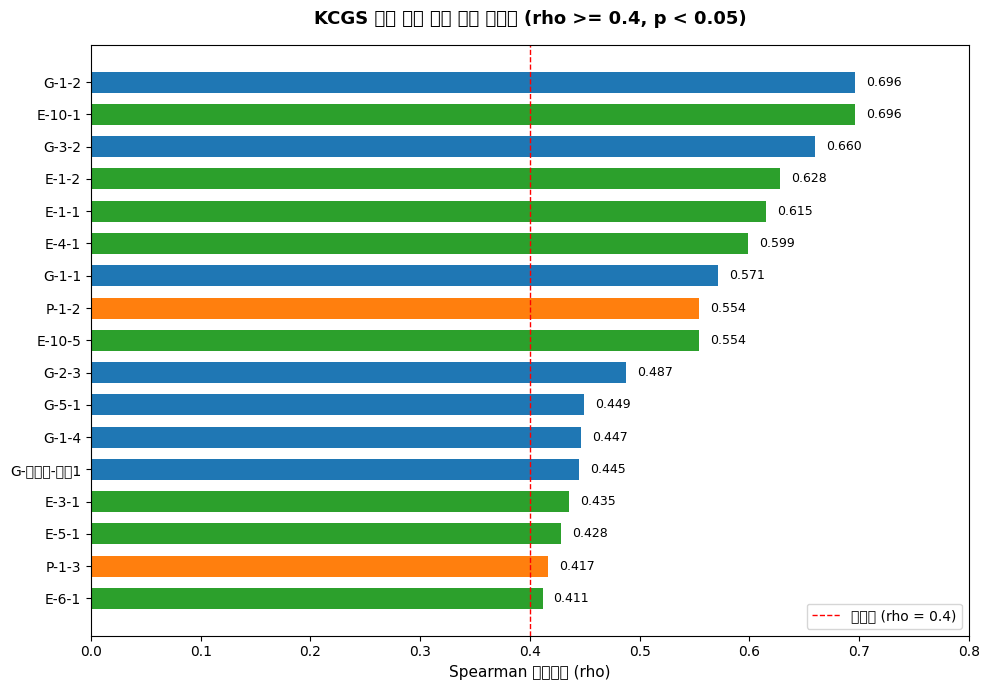

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Colab 기준)
!apt-get install -y fonts-nanum > /dev/null
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 유의 지표 필터링 (rho >= 0.4 & p_raw < 0.05)
plot_df = df_result[(df_result['rho'] >= 0.4) & (df_result['p_raw'] < 0.05)].sort_values('rho', ascending=True)

plt.figure(figsize=(10, 7))
palette = {'환경': '#2ca02c', '지배구조': '#1f77b4', '정보공시': '#ff7f0e'}
bars = plt.barh(plot_df['항목코드'], plot_df['rho'], color=[palette[d] for d in plot_df['영역']], height=0.65)

plt.axvline(0.4, color='red', linestyle='--', linewidth=1, label='기준선 (rho = 0.4)')
plt.xlabel('Spearman 상관계수 (rho)', fontsize=11)
plt.title('KCGS 등급 연계 핵심 유효 지표군 (rho >= 0.4, p < 0.05)', fontsize=13, fontweight='bold', pad=15)
plt.xlim(0, 0.8)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.01, bar.get_y() + bar.get_height()/2, f'{w:.3f}', va='center', fontsize=9)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()